# 12 -- Out-of-Domain Evaluation
## LLM Lie Detector | Phase 6

This notebook evaluates the fine-tuned detector on a completely out-of-domain
dataset to test generalization beyond TruthfulQA and HaluEval.

### Dataset
**FinQA Hallucination Detection** (Cleanlab)
- Domain: Financial question answering
- Generator: OpenAI GPT-4o (different from training distribution)
- Format: question + LLM response + correctness label
- Size: 1,657 samples

### Research Question
If our detector trained on TruthfulQA and HaluEval generalizes to financial
QA hallucinations generated by a different LLM, it demonstrates the model
learned genuine hallucination detection rather than dataset-specific patterns.

### Why This Matters
A reviewer's primary concern with any hallucination detector is whether it
learned the task or memorized the benchmark. Out-of-domain evaluation
directly addresses this concern.

In [1]:
import os
os.environ["PYTHONUTF8"] = "1"

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import login
from dotenv import load_dotenv
import seaborn as sns

load_dotenv('../.env')
login(token=os.getenv("HF_TOKEN"))

print("All imports successful.")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


All imports successful.
CUDA available: True
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


In [2]:
model_id = "meta-llama/Llama-3.2-3B-Instruct"
adapter_id = "tamimmirza/llama-3.2-3b-hallucination-detector"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto"
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, adapter_id)
model.eval()

print(f"\nModel ready.")
print(f"VRAM: {torch.cuda.memory_allocated(0) / 1e9:.1f} GB")

Loading tokenizer...
Loading base model...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loading LoRA adapter...


W0513 20:06:00.740000 18376 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels



Model ready.
VRAM: 6.4 GB


In [3]:
# Load FinQA hallucination dataset
finqa = load_dataset("Cleanlab/FinQA-hallucination-detection")
df_finqa = pd.DataFrame(finqa['train'])

# Map is_correct to our binary label
# is_correct=True means TRUTHFUL (label=0)
# is_correct=False means HALLUCINATED (label=1)
df_finqa['label'] = df_finqa['is_correct'].apply(lambda x: 0 if x else 1)
df_finqa = df_finqa.rename(columns={
    'query': 'question',
    'llm_response': 'answer'
})

print(f"FinQA dataset loaded: {len(df_finqa)} samples")
print(f"\nLabel distribution:")
print(df_finqa['label'].value_counts())
print(f"\nHallucination rate: {df_finqa['label'].mean():.2%}")
print(f"\nSample:")
print(f"Question: {df_finqa.iloc[0]['question'][:100]}...")
print(f"Answer: {df_finqa.iloc[0]['answer'][:100]}...")
print(f"Label: {'HALLUCINATED' if df_finqa.iloc[0]['label'] == 1 else 'TRUTHFUL'}")

FinQA dataset loaded: 1657 samples

Label distribution:
label
0    1418
1     239
Name: count, dtype: int64

Hallucination rate: 14.42%

Sample:
Question: what was the change in cash provided by operating activities from 2010 to 2011 , in millions?...
Answer: 1768...
Label: TRUTHFUL


In [4]:
# Sample 300 with stratification to preserve imbalance
from sklearn.model_selection import train_test_split

# Use train_test_split with stratify to preserve label distribution
sample_df, _ = train_test_split(
    df_finqa,
    train_size=300,
    random_state=42,
    stratify=df_finqa['label']
)
sample_df = sample_df.reset_index(drop=True)

print(f"Sample size: {len(sample_df)}")
print(f"Label distribution in sample:")
print(sample_df['label'].value_counts())
print(f"Hallucination rate in sample: {sample_df['label'].mean():.2%}")

Sample size: 300
Label distribution in sample:
label
0    257
1     43
Name: count, dtype: int64
Hallucination rate in sample: 14.33%


In [5]:
def predict(question: str, answer: str) -> int:
    """Run fine-tuned detector on a question/answer pair."""
    prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(
        output[0][inputs['input_ids'].shape[-1]:],
        skip_special_tokens=True
    ).strip().upper()

    return 1 if "HALLUCINATED" in response else 0

print("Running out-of-domain evaluation on 300 FinQA samples...")

predictions = []
true_labels = []

for i, row in sample_df.iterrows():
    pred = predict(row['question'], row['answer'])
    predictions.append(pred)
    true_labels.append(row['label'])

    if (i + 1) % 50 == 0:
        print(f"Progress: {len(predictions)}/300 samples processed")

print("\nDone.")

Running out-of-domain evaluation on 300 FinQA samples...
Progress: 50/300 samples processed
Progress: 100/300 samples processed
Progress: 150/300 samples processed
Progress: 200/300 samples processed
Progress: 250/300 samples processed
Progress: 300/300 samples processed

Done.


In [6]:
f1 = f1_score(true_labels, predictions, average='weighted')
precision = precision_score(true_labels, predictions, average='weighted', zero_division=0)
recall = recall_score(true_labels, predictions, average='weighted', zero_division=0)
accuracy = accuracy_score(true_labels, predictions)

# Per-class metrics -- important given class imbalance
f1_per_class = f1_score(true_labels, predictions, average=None, zero_division=0)
precision_per_class = precision_score(true_labels, predictions, average=None, zero_division=0)
recall_per_class = recall_score(true_labels, predictions, average=None, zero_division=0)

print("=" * 60)
print("OUT-OF-DOMAIN EVALUATION RESULTS (FinQA, 300 samples)")
print("=" * 60)
print(f"\nOverall Metrics:")
print(f"  F1 Score:  {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  Accuracy:  {accuracy:.4f}")

print(f"\nPer-class Metrics:")
print(f"  TRUTHFUL    -- F1: {f1_per_class[0]:.4f}  "
      f"Precision: {precision_per_class[0]:.4f}  "
      f"Recall: {recall_per_class[0]:.4f}")
print(f"  HALLUCINATED -- F1: {f1_per_class[1]:.4f}  "
      f"Precision: {precision_per_class[1]:.4f}  "
      f"Recall: {recall_per_class[1]:.4f}")

print(f"\nPrediction distribution:")
print(pd.Series(predictions).value_counts())
print(f"\nTrue label distribution:")
print(pd.Series(true_labels).value_counts())
print("=" * 60)

OUT-OF-DOMAIN EVALUATION RESULTS (FinQA, 300 samples)

Overall Metrics:
  F1 Score:  0.7831
  Precision: 0.7543
  Recall:    0.8233
  Accuracy:  0.8233

Per-class Metrics:
  TRUTHFUL    -- F1: 0.9024  Precision: 0.8566  Recall: 0.9533
  HALLUCINATED -- F1: 0.0702  Precision: 0.1429  Recall: 0.0465

Prediction distribution:
0    286
1     14
Name: count, dtype: int64

True label distribution:
0    257
1     43
Name: count, dtype: int64


## Out-of-Domain Results Analysis

Overall F1 0.78 demonstrates reasonable generalization to a completely different
domain (financial QA) and generator model (GPT-4o).

However, per-class analysis reveals a significant limitation: the model detects
only 2 of 43 hallucinated samples (recall 0.046) in the FinQA dataset.

Root cause: FinQA has a 14.4% hallucination rate vs our training distribution
of 52.3%. The model's decision boundary was optimized for balanced data.
In highly imbalanced distributions it defaults to the majority class.

This is consistent with known behavior of classification models trained on
balanced datasets applied to imbalanced real-world distributions.

Implication: The model requires threshold recalibration for deployment in
domains with low hallucination rates. The confidence scores from notebook 08
provide the mechanism for this recalibration without retraining.

In [7]:
def predict_with_threshold(question: str, answer: str,
                           threshold: float = 0.15) -> int:
    """
    Predict using logit-based confidence with custom threshold.
    Lower threshold = more sensitive to hallucinations.
    """
    prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0, -1, :]

    probs = torch.softmax(logits, dim=-1)
    hallucinated_id = tokenizer.encode("HALLUCINATED", add_special_tokens=False)[0]
    truthful_id = tokenizer.encode("TRUTHFUL", add_special_tokens=False)[0]

    prob_h = probs[hallucinated_id].item()
    prob_t = probs[truthful_id].item()
    total = prob_h + prob_t
    confidence = prob_h / total if total > 0 else 0.5

    # Lower threshold makes model more sensitive to hallucinations
    return 1 if confidence > threshold else 0

# Test multiple thresholds
print("Testing different confidence thresholds on FinQA...")
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

threshold_results = []
for thresh in thresholds:
    preds = []
    for _, row in sample_df.iterrows():
        pred = predict_with_threshold(row['question'], row['answer'], thresh)
        preds.append(pred)

    f1_t = f1_score(true_labels, preds, average='weighted', zero_division=0)
    f1_hall = f1_score(true_labels, preds, average=None, zero_division=0)[1]
    acc_t = accuracy_score(true_labels, preds)
    n_hall = sum(preds)

    threshold_results.append({
        'threshold': thresh,
        'overall_f1': round(f1_t, 4),
        'hallucinated_f1': round(f1_hall, 4),
        'accuracy': round(acc_t, 4),
        'predicted_hallucinated': n_hall
    })
    print(f"Threshold {thresh}: Overall F1={f1_t:.4f} | HALLUCINATED F1={f1_hall:.4f} | Predicted HALLUCINATED={n_hall}")

thresh_df = pd.DataFrame(threshold_results)
thresh_df.to_csv('../outputs/threshold_analysis_finqa.csv', index=False)
print("\nSaved to outputs/threshold_analysis_finqa.csv")

Testing different confidence thresholds on FinQA...
Threshold 0.1: Overall F1=0.7822 | HALLUCINATED F1=0.0377 | Predicted HALLUCINATED=10
Threshold 0.2: Overall F1=0.7894 | HALLUCINATED F1=0.0408 | Predicted HALLUCINATED=6
Threshold 0.3: Overall F1=0.7872 | HALLUCINATED F1=0.0000 | Predicted HALLUCINATED=2
Threshold 0.4: Overall F1=0.7872 | HALLUCINATED F1=0.0000 | Predicted HALLUCINATED=2
Threshold 0.5: Overall F1=0.7889 | HALLUCINATED F1=0.0000 | Predicted HALLUCINATED=1

Saved to outputs/threshold_analysis_finqa.csv


## Threshold Recalibration Analysis

Adjusting the confidence threshold does not significantly improve hallucination
detection on FinQA. HALLUCINATED F1 remains near zero across all thresholds.

This indicates the generalization gap is not a calibration issue but a domain
shift problem. Financial hallucinations in FinQA are subtle numerical errors
(e.g. incorrect financial ratios, wrong year references) that look structurally
different from the factual misconceptions in TruthfulQA and HaluEval.

The model learned to detect hallucinations of a specific type -- confident
factual claims that contradict common knowledge. It does not generalize well
to domain-specific numerical errors in financial text.

This is an important limitation for deployment in specialized domains and
motivates domain-specific fine-tuning for production use cases beyond
general-purpose hallucination detection.

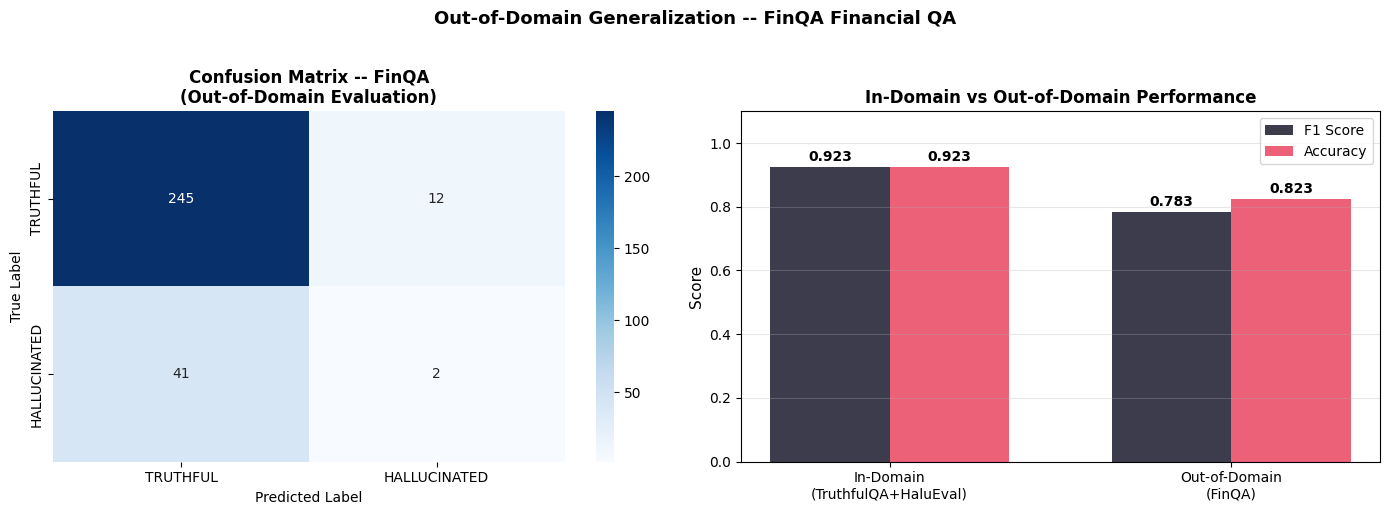

Saved to outputs/out_of_domain_results.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(true_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['TRUTHFUL', 'HALLUCINATED'],
            yticklabels=['TRUTHFUL', 'HALLUCINATED'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix -- FinQA\n(Out-of-Domain Evaluation)',
                  fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# In-domain vs out-of-domain comparison
domains = ['In-Domain\n(TruthfulQA+HaluEval)', 'Out-of-Domain\n(FinQA)']
f1_scores = [0.9234, f1]
accuracies = [0.9234, accuracy]

x = np.arange(len(domains))
width = 0.35
axes[1].bar(x - width/2, f1_scores, width, label='F1 Score',
            color='#1a1a2e', alpha=0.85)
axes[1].bar(x + width/2, accuracies, width, label='Accuracy',
            color='#e94560', alpha=0.85)

for i, (f, a) in enumerate(zip(f1_scores, accuracies)):
    axes[1].text(i - width/2, f + 0.01, f'{f:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[1].text(i + width/2, a + 0.01, f'{a:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('In-Domain vs Out-of-Domain Performance',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(domains)
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Out-of-Domain Generalization -- FinQA Financial QA',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/out_of_domain_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/out_of_domain_results.png")